# Notebook 03: Paralelismo, Benchmarks y Patrones Avanzados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/fdd_p26/blob/main/clase/16_computo/code/03_paralelismo_benchmarks.ipynb)

**Módulo 16 — Clase 3**

Este notebook acompaña los archivos `04b_asyncio_patrones.md`, `05_paralelismo.md`, `06_librerias_y_decision.md`.

Secciones **** se trabajan durante la sesión.  
Secciones **** se completan después.

---

In [21]:
import asyncio
import time
import threading
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

print(f'Python {sys.version}')
print(f'CPU cores disponibles: {os.cpu_count()}')

Python 3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
CPU cores disponibles: 8


## Sección 1: create_task vs gather — trabajo intermedio "gratis"

**Hipótesis:** con `create_task`, podemos ejecutar trabajo independiente mientras una tarea espera.
El trabajo intermedio debe ocurrir "gratis" — durante el wait de la tarea lanzada.

In [22]:
async def tarea_io(nombre: str, duracion: float) -> str:
    """Simula I/O-bound: wait(τᵢ) ≠ ∅"""
    await asyncio.sleep(duracion)
    return f"{nombre} completada"

def trabajo_cpu_ligero(n: int) -> int:
    """Trabajo CPU-bound ligero: exec(τⱼ) mientras τᵢ espera"""
    return sum(range(n))

# --- Comparación: gather vs create_task ---

# gather: barrera — espera TODAS antes de continuar
print("=== gather: barrera ===")
t0 = time.perf_counter()
r1, r2 = await asyncio.gather(
    tarea_io("A", 1.0),
    tarea_io("B", 1.0),
)
t_gather = time.perf_counter() - t0
print(f"Resultados: {r1}, {r2}")
print(f"Tiempo: {t_gather:.2f}s (esperado ~1s)")
print()

# create_task: lanzar y continuar con trabajo intermedio
print("=== create_task + trabajo intermedio ===")
t0 = time.perf_counter()

# ① Lanzar τᵢ en background
tarea_a = asyncio.create_task(tarea_io("A", 1.0))

# ② Trabajo independiente DURANTE el wait de A
t_trabajo = time.perf_counter()
resultado_cpu = trabajo_cpu_ligero(5_000_000)   # ~200ms de CPU
t_trabajo = time.perf_counter() - t_trabajo
print(f"  Trabajo CPU completado en {t_trabajo:.2f}s (durante wait de A)")

# ③ Punto de dependencia: necesitamos el resultado de A
resultado_a = await tarea_a
t_create_task = time.perf_counter() - t0

print(f"  {resultado_a}")
print(f"Tiempo total: {t_create_task:.2f}s (esperado ~max(1s, tiempo_cpu))")
print()
print(f"Observa: el trabajo CPU ({t_trabajo:.2f}s) fue 'gratis' — ocurrió durante el wait de A.")
print(f"Sin create_task, hubiera sumado {1.0 + t_trabajo:.2f}s en lugar de {t_create_task:.2f}s")

=== gather: barrera ===
Resultados: A completada, B completada
Tiempo: 1.00s (esperado ~1s)

=== create_task + trabajo intermedio ===
  Trabajo CPU completado en 0.15s (durante wait de A)
  A completada
Tiempo total: 1.15s (esperado ~max(1s, tiempo_cpu))

Observa: el trabajo CPU (0.15s) fue 'gratis' — ocurrió durante el wait de A.
Sin create_task, hubiera sumado 1.15s en lugar de 1.15s


## Sección 2: as_completed — procesar resultados conforme llegan

Con tareas de **duración variable**, `gather` espera al más lento antes de procesar cualquier resultado.
`as_completed` permite procesar cada resultado tan pronto como está disponible.

In [24]:
import random

async def buscar_fuente(nombre: str, latencia: float) -> str:
    """Simula búsqueda en una fuente externa con latencia variable"""
    await asyncio.sleep(latencia)
    return f"resultado de {nombre} (tardó {latencia:.1f}s)"

fuentes = [
    ("Wikipedia", 0.5),
    ("ArXiv",     2.1),
    ("GitHub",    0.8),
    ("PubMed",    1.5),
    ("DuckDuck",  0.3),
]

# --- Con gather: espera el más lento ---
print("=== asyncio.gather: espera al más lento ===")
t0 = time.perf_counter()
resultados = await asyncio.gather(
    *[buscar_fuente(nombre, lat) for nombre, lat in fuentes]
)
t_gather = time.perf_counter() - t0
print(f"Todos los resultados disponibles a los {t_gather:.2f}s")
for r in resultados:
    print(f"  {r}")
print()

# --- Con as_completed: procesar conforme llegan ---
print("=== asyncio.as_completed: procesa conforme llegan ===")
t0 = time.perf_counter()
tareas = [asyncio.create_task(buscar_fuente(n, l)) for n, l in fuentes]

orden_llegada = []
for tarea_completada in asyncio.as_completed(tareas):
    resultado = await tarea_completada
    t_llegada = time.perf_counter() - t0
    print(f"  t={t_llegada:.2f}s -> {resultado}")
    orden_llegada.append(resultado)

print()
print("Observa: el orden de llegada es por latencia, no por orden de creación.")
print("El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.")

=== asyncio.gather: espera al más lento ===
Todos los resultados disponibles a los 2.10s
  resultado de Wikipedia (tardó 0.5s)
  resultado de ArXiv (tardó 2.1s)
  resultado de GitHub (tardó 0.8s)
  resultado de PubMed (tardó 1.5s)
  resultado de DuckDuck (tardó 0.3s)

=== asyncio.as_completed: procesa conforme llegan ===
  t=0.30s -> resultado de DuckDuck (tardó 0.3s)
  t=0.50s -> resultado de Wikipedia (tardó 0.5s)
  t=0.80s -> resultado de GitHub (tardó 0.8s)
  t=1.50s -> resultado de PubMed (tardó 1.5s)
  t=2.10s -> resultado de ArXiv (tardó 2.1s)

Observa: el orden de llegada es por latencia, no por orden de creación.
El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.


---

## Sección 3: asyncio.Queue — productor-consumidor

Implementa el patrón productor-consumidor usando `asyncio.Queue`.

In [26]:
import asyncio
import time

# TAREA 3: Implementar el patrón productor-consumidor
#
# Escenario: un productor genera 10 peticiones de chatbot a ritmo de 2/s.
# 3 workers las procesan (cada una tarda ~0.5s).
# Mide: ¿cuándo termina todo si hay 1, 2 o 3 workers?

N_PETICIONES = 10
RITMO_PRODUCCION = 0.5   # segundos entre peticiones
T_PROCESAMIENTO = 0.5    # segundos que tarda cada petición


async def productor(queue: asyncio.Queue, n: int, n_workers: int):
    for i in range(n):
        await asyncio.sleep(RITMO_PRODUCCION)   # llega una nueva petición cada 0.5s
        await queue.put(i)
        print(f"[productor] produjo petición {i} | cola={queue.qsize()}")

    # sentinels para apagar workers
    for _ in range(n_workers):
        await queue.put(None)


async def worker(queue: asyncio.Queue, nombre: str):
    while True:
        item = await queue.get()

        if item is None:
            queue.task_done()
            print(f"[{nombre}] termina")
            break

        print(f"[{nombre}] procesa petición {item}")
        await asyncio.sleep(T_PROCESAMIENTO)
        print(f"[{nombre}] terminó petición {item}")
        queue.task_done()


async def correr_experimento(n_workers: int):
    print(f"\n=== Experimento con {n_workers} worker(s) ===")
    queue = asyncio.Queue()

    t0 = time.perf_counter()

    prod_task = asyncio.create_task(productor(queue, N_PETICIONES, n_workers))
    workers = [
        asyncio.create_task(worker(queue, f"worker-{i+1}"))
        for i in range(n_workers)
    ]

    await asyncio.gather(prod_task, *workers)

    t_total = time.perf_counter() - t0
    print(f"Tiempo total con {n_workers} worker(s): {t_total:.2f}s")
    return t_total


resultados = {}
for n_workers in [1, 2, 3]:
    resultados[n_workers] = await correr_experimento(n_workers)

print("\n=== Resumen ===")
for n_workers, t_total in resultados.items():
    print(f"{n_workers} worker(s): {t_total:.2f}s")

print("\nInterpretación:")
print("Como producir una petición tarda 0.5s y procesarla también tarda 0.5s,")
print("con 1 worker ya casi se empalma perfecto con la producción.")
print("Por eso agregar 2 o 3 workers da poca o ninguna mejora grande en tiempo total,")
print("porque el cuello de botella termina siendo el ritmo de llegada del productor.")


=== Experimento con 1 worker(s) ===
[productor] produjo petición 0 | cola=1
[worker-1] procesa petición 0
[productor] produjo petición 1 | cola=1
[worker-1] terminó petición 0
[worker-1] procesa petición 1
[productor] produjo petición 2 | cola=1
[worker-1] terminó petición 1
[worker-1] procesa petición 2
[productor] produjo petición 3 | cola=1
[worker-1] terminó petición 2
[worker-1] procesa petición 3
[productor] produjo petición 4 | cola=1
[worker-1] terminó petición 3
[worker-1] procesa petición 4
[productor] produjo petición 5 | cola=1
[worker-1] terminó petición 4
[worker-1] procesa petición 5
[productor] produjo petición 6 | cola=1
[worker-1] terminó petición 5
[worker-1] procesa petición 6
[productor] produjo petición 7 | cola=1
[worker-1] terminó petición 6
[worker-1] procesa petición 7
[productor] produjo petición 8 | cola=1
[worker-1] terminó petición 7
[worker-1] procesa petición 8
[productor] produjo petición 9 | cola=1
[worker-1] terminó petición 8
[worker-1] procesa peti

## Sección 4: fire-and-forget — excepción silenciada vs tracked

In [29]:
# TAREA 4: Demostrar fire-and-forget con excepción silenciada
import asyncio

async def tarea_que_falla():
    await asyncio.sleep(0.1)
    raise ValueError("¡Error en la tarea!")

# Anti-patrón: fire-and-forget sin tracking
print("=== Anti-patrón: fire-and-forget ===")
t = asyncio.create_task(tarea_que_falla())   # ← lanza la tarea
await asyncio.sleep(0.5)                     # ← la excepción ocurre, pero...
print("No se vio ningún error claro en flujo normal: la excepción quedó sin manejar directamente.")
print()

# Patrón correcto: tracked con callback
def log_resultado(fut: asyncio.Future):
    exc = fut.exception()
    if exc is not None:
        print(f"[callback] tarea terminó con excepción: {type(exc).__name__}: {exc}")
    else:
        print(f"[callback] tarea terminó bien con resultado: {fut.result()}")

print("=== Patrón correcto: tracked con add_done_callback ===")
t2 = asyncio.create_task(tarea_que_falla())
t2.add_done_callback(log_resultado)

await asyncio.sleep(0.5)
print("Ahora sí la excepción quedó registrada explícitamente.")

Task exception was never retrieved
future: <Task finished name='Task-170' coro=<tarea_que_falla() done, defined at /tmp/ipykernel_17938/2234389794.py:4> exception=ValueError('¡Error en la tarea!')>
Traceback (most recent call last):
  File "/tmp/ipykernel_17938/2234389794.py", line 6, in tarea_que_falla
    raise ValueError("¡Error en la tarea!")
ValueError: ¡Error en la tarea!


=== Anti-patrón: fire-and-forget ===
No se vio ningún error claro en flujo normal: la excepción quedó sin manejar directamente.

=== Patrón correcto: tracked con add_done_callback ===
[callback] tarea terminó con excepción: ValueError: ¡Error en la tarea!
Ahora sí la excepción quedó registrada explícitamente.


## Sección 5: Benchmark asyncio vs threading — I/O-bound

Compara asyncio y ThreadPoolExecutor para tareas I/O-bound.
Ambos deberían funcionar — ¿cuál es más rápido y más simple?

In [30]:
import time
import asyncio
import requests  # síncrono
from concurrent.futures import ThreadPoolExecutor

# Simula I/O-bound síncrono (para ThreadPoolExecutor)
def io_bound_sync(duration: float) -> str:
    time.sleep(duration)   # simula requests.get, cursor.execute, etc.
    return "resultado"

# Simula I/O-bound async
async def io_bound_async(duration: float) -> str:
    await asyncio.sleep(duration)
    return "resultado"

N = 20
DUR = 0.2   # cada tarea tarda 0.2s

# --- ThreadPoolExecutor ---
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=N) as pool:
    futures = [pool.submit(io_bound_sync, DUR) for _ in range(N)]
    resultados_thread = [f.result() for f in futures]
t_thread = time.perf_counter() - t0
print(f"ThreadPoolExecutor ({N} workers): {t_thread:.2f}s  (esperado ~{DUR:.1f}s)")

# --- asyncio.gather ---
t0 = time.perf_counter()
resultados_async = await asyncio.gather(*[io_bound_async(DUR) for _ in range(N)])
t_async = time.perf_counter() - t0
print(f"asyncio.gather ({N} tasks):        {t_async:.2f}s  (esperado ~{DUR:.1f}s)")

# --- Comparación ---
ratio = t_thread / t_async
print(f"\nRelación thread/async: {ratio:.2f}x")

print("\nInterpretación:")
print("Ambos funcionan bien para I/O-bound y el tiempo total debería acercarse a la latencia")
print("de una sola tarea (~0.2s), porque las esperas se solapan.")
print("asyncio suele tener menos overhead y escalar mejor cuando las operaciones ya son async.")
print("ThreadPoolExecutor conviene cuando tu librería es bloqueante/síncrona y no tienes versión async.")

ThreadPoolExecutor (20 workers): 0.21s  (esperado ~0.2s)
asyncio.gather (20 tasks):        0.20s  (esperado ~0.2s)

Relación thread/async: 1.03x

Interpretación:
Ambos funcionan bien para I/O-bound y el tiempo total debería acercarse a la latencia
de una sola tarea (~0.2s), porque las esperas se solapan.
asyncio suele tener menos overhead y escalar mejor cuando las operaciones ya son async.
ThreadPoolExecutor conviene cuando tu librería es bloqueante/síncrona y no tienes versión async.


## Sección 6: threading vs multiprocessing — CPU-bound con el GIL en números

Confirma empíricamente la predicción del GIL: threading no escala para CPU-bound, multiprocessing sí.

/home/david/fdd_p26/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:50: RuntimeWarning: coroutine 'main' was never awaited
  from .path import Path


Secuencial (8 tareas): 2.44s (baseline)

=== n_workers = 1 ===
threading:       0.31s | speedup vs secuencial: 7.95x
multiprocessing: 0.32s | speedup vs secuencial: 7.59x

=== n_workers = 2 ===
threading:       0.62s | speedup vs secuencial: 3.95x
multiprocessing: 0.31s | speedup vs secuencial: 7.85x

=== n_workers = 4 ===
threading:       1.21s | speedup vs secuencial: 2.02x
multiprocessing: 0.37s | speedup vs secuencial: 6.68x

=== n_workers = 8 ===
threading:       2.59s | speedup vs secuencial: 0.94x
multiprocessing: 0.70s | speedup vs secuencial: 3.49x



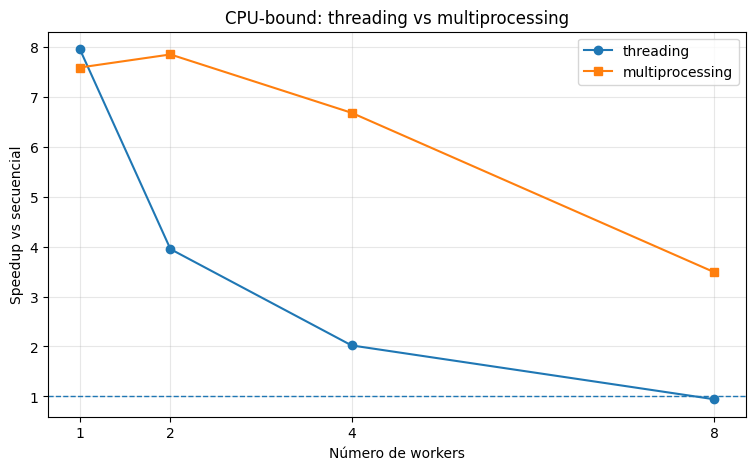

Conclusión:
En CPU-bound, threading suele quedarse cerca de 1x o incluso empeorar
porque los hilos comparten el GIL y no hay paralelismo real de bytecode Python.
Multiprocessing sí puede escalar mejor porque cada proceso tiene su propio GIL
y puede usar distintos cores del CPU.


In [31]:
import os
import time
import threading
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# IMPORTANTE: ProcessPoolExecutor requiere funciones picklables
# La función debe estar definida a nivel de módulo (no como lambda ni nested)

def tarea_cpu(n: int) -> int:
    """CPU-bound pura: wait(t_i) = 0"""
    return sum(range(n))

N_TRABAJO = 20_000_000   # ajusta según tu máquina
N_WORKERS_LIST = [1, 2, 4, os.cpu_count()]

# --- Secuencial (baseline) ---
n = N_WORKERS_LIST[-1]   # baseline con el mismo número de tareas que el caso más grande
t0 = time.perf_counter()
for _ in range(n):
    tarea_cpu(N_TRABAJO)
t_seq = time.perf_counter() - t0
print(f"Secuencial ({n} tareas): {t_seq:.2f}s (baseline)")
print()

# Helpers para threading
def worker_thread(n_trabajo: int):
    tarea_cpu(n_trabajo)

# Resultados
thread_times = []
proc_times = []
thread_speedups = []
proc_speedups = []

for n_workers in N_WORKERS_LIST:
    print(f"=== n_workers = {n_workers} ===")

    # --- Threading ---
    hilos = []
    t0 = time.perf_counter()
    for _ in range(n_workers):
        h = threading.Thread(target=worker_thread, args=(N_TRABAJO,))
        hilos.append(h)
        h.start()
    for h in hilos:
        h.join()
    t_thread = time.perf_counter() - t0
    s_thread = t_seq / t_thread

    # --- Multiprocessing ---
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        resultados = list(pool.map(tarea_cpu, [N_TRABAJO] * n_workers))
    t_proc = time.perf_counter() - t0
    s_proc = t_seq / t_proc

    thread_times.append(t_thread)
    proc_times.append(t_proc)
    thread_speedups.append(s_thread)
    proc_speedups.append(s_proc)

    print(f"threading:       {t_thread:.2f}s | speedup vs secuencial: {s_thread:.2f}x")
    print(f"multiprocessing: {t_proc:.2f}s | speedup vs secuencial: {s_proc:.2f}x")
    print()

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(N_WORKERS_LIST, thread_speedups, marker='o', label='threading')
plt.plot(N_WORKERS_LIST, proc_speedups, marker='s', label='multiprocessing')
plt.axhline(1.0, linestyle='--', linewidth=1)
plt.xlabel("Número de workers")
plt.ylabel("Speedup vs secuencial")
plt.title("CPU-bound: threading vs multiprocessing")
plt.xticks(N_WORKERS_LIST)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Conclusión:")
print("En CPU-bound, threading suele quedarse cerca de 1x o incluso empeorar")
print("porque los hilos comparten el GIL y no hay paralelismo real de bytecode Python.")
print("Multiprocessing sí puede escalar mejor porque cada proceso tiene su propio GIL")
print("y puede usar distintos cores del CPU.")

## Sección 7: joblib vs ProcessPoolExecutor — misma tarea

In [35]:
!pip install joblib

In [36]:
import time
from concurrent.futures import ProcessPoolExecutor

try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except ImportError:
    print("joblib no instalado — corre primero: !pip install joblib")
    JOBLIB_OK = False

if JOBLIB_OK:
    datos = list(range(1_000_000, 1_001_000))   # 1000 tareas

    # ProcessPoolExecutor
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=4) as pool:
        resultados_ppe = list(pool.map(tarea_cpu, datos))
    t_ppe = time.perf_counter() - t0
    print(f"ProcessPoolExecutor (4 workers): {t_ppe:.2f}s")

    # joblib
    t0 = time.perf_counter()
    resultados_jl = Parallel(n_jobs=4)(delayed(tarea_cpu)(n) for n in datos)
    t_jl = time.perf_counter() - t0
    print(f"joblib.Parallel (n_jobs=4):      {t_jl:.2f}s")

    assert resultados_ppe == resultados_jl, "¡resultados diferentes!"
    print("\nResultados idénticos: ✓")

    print("\n¿Cuándo preferirías joblib sobre ProcessPoolExecutor?")
    print("- joblib cuando quieres una interfaz más simple para paralelizar loops/map")
    print("- joblib cuando trabajas mucho con numpy/scikit-learn")
    print("- joblib porque su backend 'loky' suele manejar bien procesos y serialización")
    print("- ProcessPoolExecutor cuando quieres más control fino sobre futures, submit/map y flujo")

ProcessPoolExecutor (4 workers): 4.82s
joblib.Parallel (n_jobs=4):      5.22s

Resultados idénticos: ✓

¿Cuándo preferirías joblib sobre ProcessPoolExecutor?
- joblib cuando quieres una interfaz más simple para paralelizar loops/map
- joblib cuando trabajas mucho con numpy/scikit-learn
- joblib porque su backend 'loky' suele manejar bien procesos y serialización
- ProcessPoolExecutor cuando quieres más control fino sobre futures, submit/map y flujo


## Sección 8: Anti-patrón lambda (PicklingError)

In [37]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# TAREA 8: Reproducir el PicklingError con lambda en ProcessPoolExecutor

# Anti-patrón: lambda no puede ser serializada entre procesos
try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(lambda x: x**2, [1, 2, 3, 4]))
    print("¿Sin error? (puede pasar en algunos sistemas)")
    print(resultados)
except Exception as e:
    print(f"Error esperado: {type(e).__name__}: {e}")

print()

# FIX 1: función a nivel de módulo
def al_cuadrado(x: int) -> int:
    return x ** 2

with ProcessPoolExecutor(max_workers=2) as pool:
    resultados_fix1 = list(pool.map(al_cuadrado, [1, 2, 3, 4]))

print("Fix 1 — función a nivel de módulo:")
print(resultados_fix1)

# FIX 2: functools.partial con función picklable
def potencia(x: int, exp: int) -> int:
    return x ** exp

cuadrado = partial(potencia, exp=2)

with ProcessPoolExecutor(max_workers=2) as pool:
    resultados_fix2 = list(pool.map(cuadrado, [1, 2, 3, 4]))

print("\nFix 2 — partial sobre función picklable:")
print(resultados_fix2)

assert resultados_fix1 == resultados_fix2 == [1, 4, 9, 16]
print("\nResultados correctos y sin error: ✓")

Error esperado: PicklingError: Can't pickle <function <lambda> at 0x737ef3d7c680>: attribute lookup <lambda> on __main__ failed

Fix 1 — función a nivel de módulo:
[1, 4, 9, 16]

Fix 2 — partial sobre función picklable:
[1, 4, 9, 16]

Resultados correctos y sin error: ✓


## Sección 9: Pool por petición vs pool compartido — medir diferencia

In [38]:
import time
from concurrent.futures import ProcessPoolExecutor

# Asegúrate de que tarea_cpu esté definida a nivel de módulo
def tarea_cpu(n: int) -> int:
    return sum(range(n))

# TAREA 9: Comparar overhead de crear pool por petición vs pool compartido

N_PETICIONES = 20

# --- Anti-patrón: nuevo pool por petición ---
t0 = time.perf_counter()
for _ in range(N_PETICIONES):
    with ProcessPoolExecutor(max_workers=2) as pool:
        list(pool.map(tarea_cpu, [100_000, 100_000]))
t_pool_por_peticion = time.perf_counter() - t0
print(f"Pool por petición ({N_PETICIONES} veces): {t_pool_por_peticion:.2f}s")

# --- Correcto: pool compartido ---
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=2) as pool_compartido:
    for _ in range(N_PETICIONES):
        list(pool_compartido.map(tarea_cpu, [100_000, 100_000]))
t_pool_compartido = time.perf_counter() - t0
print(f"Pool compartido ({N_PETICIONES} peticiones): {t_pool_compartido:.2f}s")

# --- Comparación ---
ratio = t_pool_por_peticion / t_pool_compartido if t_pool_compartido > 0 else float('inf')
print(f"\nOverhead del anti-patrón: {ratio:.1f}x más lento")
print("El overhead es el costo de crear/destruir procesos N veces en lugar de una.")

Pool por petición (20 veces): 0.66s
Pool compartido (20 peticiones): 0.15s

Overhead del anti-patrón: 4.5x más lento
El overhead es el costo de crear/destruir procesos N veces en lugar de una.


## Sección 10 (opcional): run_in_executor — asyncio + ProcessPoolExecutor

Integra asyncio con ProcessPoolExecutor para manejar carga mixta (I/O + CPU).
Este es el patrón del chatbot v3 (M5b).

In [39]:
import asyncio
import time
import os
from concurrent.futures import ProcessPoolExecutor

# TAREA 10: Implementar M5b — asyncio + ProcessPoolExecutor
#
# Escenario: 10 peticiones llegan simultáneamente.
# Cada petición: consulta BD (I/O, 0.1s) + inferencia LLM local (CPU, 0.5s)
#
# Compara:
#   a) Todo en asyncio con time.sleep (bloquea el event loop durante inferencia)
#   b) asyncio para I/O + run_in_executor(ProcessPoolExecutor) para CPU

N_USUARIOS = 10
T_IO = 0.1   # wait(t_i): consulta BD
T_CPU = 0.5  # exec bloqueante: inferencia LLM

def inferencia_local(historial):
    """CPU-bound: simula inferencia del LLM local"""
    time.sleep(T_CPU)   # aquí se simula el trabajo bloqueante/CPU
    return f"respuesta para {historial}"

async def consulta_bd(user_id: int):
    await asyncio.sleep(T_IO)
    return f"historial_{user_id}"

# --- Versión a: async puro, pero con bloqueo en CPU ---
async def handle_a(user_id: int):
    historial = await consulta_bd(user_id)
    # BLOQUEA el event loop
    respuesta = inferencia_local(historial)
    return respuesta

async def version_a():
    t0 = time.perf_counter()
    resultados = await asyncio.gather(*[handle_a(i) for i in range(N_USUARIOS)])
    t_total = time.perf_counter() - t0
    return resultados, t_total

# --- Versión b: async para I/O + ProcessPoolExecutor para CPU ---
async def handle_b(user_id: int, pool: ProcessPoolExecutor):
    historial = await consulta_bd(user_id)
    loop = asyncio.get_running_loop()
    respuesta = await loop.run_in_executor(pool, inferencia_local, historial)
    return respuesta

async def version_b():
    t0 = time.perf_counter()
    max_workers = min(os.cpu_count() or 2, N_USUARIOS)
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        resultados = await asyncio.gather(*[handle_b(i, pool) for i in range(N_USUARIOS)])
    t_total = time.perf_counter() - t0
    return resultados, t_total, max_workers

# --- Ejecutar benchmark ---
resultados_a, t_a = await version_a()
resultados_b, t_b, workers_b = await version_b()

speedup = t_a / t_b

print("=== Resultados ===")
print(f"Versión a) asyncio + time.sleep bloqueante: {t_a:.2f}s")
print(f"Versión b) asyncio + ProcessPoolExecutor ({workers_b} workers): {t_b:.2f}s")
print(f"Mejora b sobre a: {speedup:.2f}x")
print()

# Fracción secuencial implícita (aprox. por petición)
# Total por petición = T_IO + T_CPU
# Parte no paralelizable dentro de una petición ~ T_IO
# Parte paralelizable/offload ~ T_CPU
f_sec = T_IO / (T_IO + T_CPU)
print(f"Fracción secuencial implícita aprox.: {f_sec:.3f} ({f_sec*100:.1f}%)")
print()

print("=== Interpretación ===")
print("En la versión a, la parte de CPU (time.sleep) bloquea el event loop,")
print("así que aunque la I/O se solape, la inferencia se serializa de facto.")
print("En la versión b, la I/O sigue en asyncio y la parte CPU se manda a procesos,")
print("permitiendo paralelismo real en la inferencia.")
print("Según la Ley de Amdahl, la mejora está limitada por la fracción secuencial")
print("(aquí, sobre todo la parte de I/O y cualquier overhead no paralelizable).")

=== Resultados ===
Versión a) asyncio + time.sleep bloqueante: 5.10s
Versión b) asyncio + ProcessPoolExecutor (8 workers): 1.18s
Mejora b sobre a: 4.32x

Fracción secuencial implícita aprox.: 0.167 (16.7%)

=== Interpretación ===
En la versión a, la parte de CPU (time.sleep) bloquea el event loop,
así que aunque la I/O se solape, la inferencia se serializa de facto.
En la versión b, la I/O sigue en asyncio y la parte CPU se manda a procesos,
permitiendo paralelismo real en la inferencia.
Según la Ley de Amdahl, la mejora está limitada por la fracción secuencial
(aquí, sobre todo la parte de I/O y cualquier overhead no paralelizable).


Cosas que puse para estudiar

In [2]:
import asyncio

async def tarea1():
    print("Inicio tarea1")
    await asyncio.sleep(2)
    print("Fin tarea1")

async def tarea2():
    print("Inicio tarea2")
    await asyncio.sleep(1)
    print("Fin tarea2")

async def main():
    await asyncio.gather(tarea1(), tarea2())

await main()

Inicio tarea1
Inicio tarea2
Fin tarea2
Fin tarea1


In [3]:
import multiprocessing
import time

def tarea(n):
    print(f"Inicio {n}")
    time.sleep(2)
    print(f"Fin {n}")

if __name__ == "__main__":
    p1 = multiprocessing.Process(target=tarea, args=(1,))
    p2 = multiprocessing.Process(target=tarea, args=(2,))

    p1.start()
    p2.start()

    p1.join()
    p2.join()

Inicio 1
Inicio 2
Fin 1
Fin 2


In [5]:
import threading
import time

def tarea(nombre):
    for i in range(3):
        print(nombre, i)
        time.sleep(1)

h1 = threading.Thread(target=tarea, args=("A",))
h2 = threading.Thread(target=tarea, args=("B",))

h1.start()
h2.start()

h1.join()
h2.join()

A 0
B 0
A 1
B 1
A 2
B 2


In [12]:
import asyncio
import requests

def tarea_bloqueante():
    return requests.get("https://google.com")

async def main():
    loop = asyncio.get_running_loop()
    resultado = await loop.run_in_executor(None, tarea_bloqueante)
    print("Terminé", resultado.status_code)

await main()

Terminé 200


In [19]:
import asyncio
import requests

def descargar(url):
    print(f"Descargando {url}")
    r = requests.get(url)
    print(f"Listo {url} ({r.status_code})")
    return r.status_code

async def main():
    loop = asyncio.get_running_loop()

    tareas = [
        loop.run_in_executor(None, descargar, "https://google.com"),
        loop.run_in_executor(None, descargar, "https://github.com"),
        loop.run_in_executor(None, descargar, "https://openai.com"),
    ]

    resultados = await asyncio.gather(*tareas)

    print("Resultados:", resultados)

await main()

Descargando https://google.com
Descargando https://github.com
Descargando https://openai.com
Listo https://openai.com (403)
Listo https://github.com (200)
Listo https://google.com (200)
Resultados: [200, 200, 403]


In [25]:
import asyncio

async def A():
    await asyncio.sleep(2)
    print("terminó A")
    return "A"

async def B():
    await asyncio.sleep(1)
    print("terminó B")
    return "B"

r = await asyncio.gather(A(), B())
print(r)

terminó B
terminó A
['A', 'B']
